# 1. Import

In [1]:
import importlib
import subprocess
import sys
import time
print(time.ctime() + '\n')

print(sys.version + '\n')

modules = ['numpy', 'matplotlib', 'astropy', 'pandas']
for module in modules:
    try:
        mod = importlib.import_module(module)
        print(f"{module:>20} : {mod.__version__}")
    except ImportError:
        print(f"{module:>20} : NOT installed. Installing...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", module])
        mod = importlib.import_module(module)
        print(f"{module:>20} : {mod.__version__} (installed now)")
        
import numpy as np
import glob, os, copy
import pandas as pd
from astropy.io import fits
from astropy.visualization import ZScaleInterval

import warnings
warnings.filterwarnings("ignore")

Mon Dec  1 03:58:10 2025

3.13.5 | packaged by Anaconda, Inc. | (main, Jun 12 2025, 16:09:02) [GCC 11.2.0]

               numpy : 2.3.5
          matplotlib : 3.10.7
             astropy : 7.2.0
              pandas : 2.3.3


### Matplotlib setting

In [2]:
from matplotlib import pyplot as plt
%matplotlib inline
from matplotlib import rc, rcParams
rc('axes', linewidth=2)
rc('xtick', top=True, bottom=True, direction='in')
rc('ytick', left=True, right=True, direction='in')

### For installing GALFIT, please refer to the website below.
* **[GALFIT homepage](https://users.obs.carnegiescience.edu/peng/work/galfit/galfit.html)**

In [3]:
current_path = os.path.abspath(".")
your_galfit_path = "/home/jhlee/Downloads/"  # the path where you will download 'galfit'
if not os.path.exists(your_galfit_path+"galfit"):
    os.chdir(your_galfit_path)  # move to download path
    os.system("wget https://users.obs.carnegiescience.edu/peng/work/galfit/galfit3-debian64.tar.gz")  # download galfit file (depending on your OS)
    os.system("tar -zxvf galfit*.tar.gz")  # make 'galfit' execution file
    os.chdir(current_path)

# 2. View the thumbnail images of sample galaxies

### Reading the sample galaxy information in the SMACS0723 field (from [Lee, J. H. et al. 2024](https://ui.adsabs.harvard.edu/abs/2024ApJ...966..113L/abstract))

In [4]:
df = pd.read_csv("test_sample_SMACS0723.csv")
n_galaxy = len(df)
df

,ID,ra,dec,z,z_flag,logmass,f200w_mag,band
0,4912,110.79649,-73.44619,1.3739,spec,10.3248,22.651,f150w
1,5040,110.76382,-73.44747,1.9774,spec,11.4344,20.805,f150w
2,6609,110.76264,-73.45838,1.9832,spec,10.5966,22.415,f150w
3,8106,110.84655,-73.43377,2.1286,spec,9.6647,24.000,f200w
4,5486,110.76472,-73.45021,3.0994,spec,10.0511,24.049,f277w


### For the exercise, there are given cutout images of six galaxies in the SMACS0723 field.
### With the pixel scale of 0.04"/pixel, these cutout images have a field of view of 10"x10".
### These cutout images show the flux unit of nJy per pixel, corresponding to the AB magnitude zeropoint of 28.9 mag.

In [5]:
pixel_scale = 0.04  # arcsec/pixel
mag_zero = 28.9  # magnitude

In [6]:
orig_image_list = [f"Input_{df['ID'].values[idx]:05d}_{df['band'].values[idx]}.fits" for idx in range(n_galaxy)]
orig_image_list  # original cutout images

['Input_04912_f150w.fits',
 'Input_05040_f150w.fits',
 'Input_06609_f150w.fits',
 'Input_08106_f200w.fits',
 'Input_05486_f277w.fits']

### Masking neighboring sources around the target galaxies is needed for good galaxy modeling by GALFIT.
### With additive source detection for neighboring galaxies, I generated the following cleaned images.

In [7]:
clean_image_list = [f"Input2_{df['ID'].values[idx]:05d}_{df['band'].values[idx]}.fits" for idx in range(n_galaxy)]
clean_image_list  # cleaned cutout images (for input images)

['Input2_04912_f150w.fits',
 'Input2_05040_f150w.fits',
 'Input2_06609_f150w.fits',
 'Input2_08106_f200w.fits',
 'Input2_05486_f277w.fits']

### Showing the cutout images

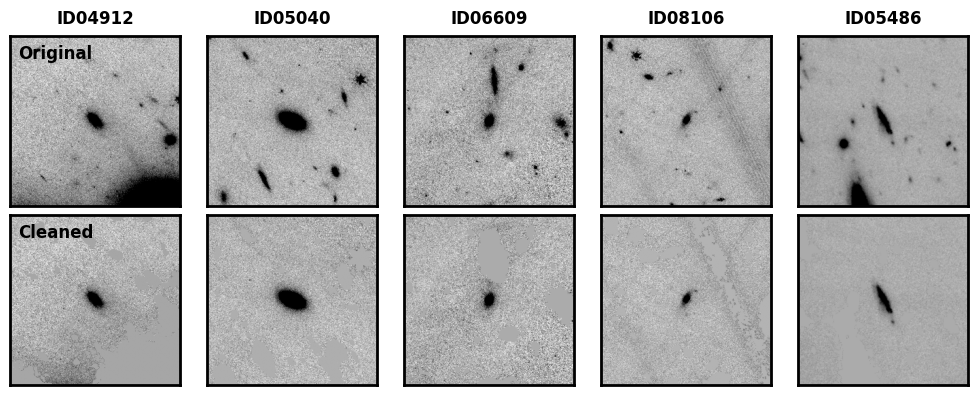

In [8]:
fig, axs = plt.subplots(2, n_galaxy, figsize=(10, 4))

for i in range(n_galaxy):
    galaxy_id = df['ID'].values[i]
    orig_data = fits.getdata(orig_image_list[i])
    clean_data = fits.getdata(clean_image_list[i])
    image_data = [orig_data, clean_data]
    for j in range(len(image_data)):
        ax = axs[j, i]
        ax.imshow(image_data[j], cmap='gray_r', origin='lower', vmin=-0.1, vmax=0.2)
        ax.tick_params(axis='both', length=0.0, labelleft=False, labelbottom=False)
        if (j == 0):
            ax.text(0.50, 1.05, f"ID{galaxy_id:05d}", fontsize=12.0, fontweight='bold',
                    transform=ax.transAxes, ha='center', va='bottom')
        if (i == 0):
            if (j == 0):
                label = "Original"
            if (j == 1):
                label = "Cleaned"
            ax.text(0.05, 0.95, label, fontsize=12.0, fontweight='bold',
                    transform=ax.transAxes, ha='left', va='top')
plt.tight_layout()

# 3. Preparation of PSF images

### Each band image has difference PSF profile, so the PSF effect has to be deconvolved for GALFIT.
### For simplicity, the PSF images were obtained from [WebbPSF](https://jwst-docs.stsci.edu/jwst-observatory-characteristics-and-performance/optics-performance-and-stability/stpsf-formerly-webbpsf).

In [9]:
psf_image_list = sorted(glob.glob("PSF_*.fits"))  # PSF images
psf_image_list

['PSF_f150w.fits', 'PSF_f200w.fits', 'PSF_f277w.fits']

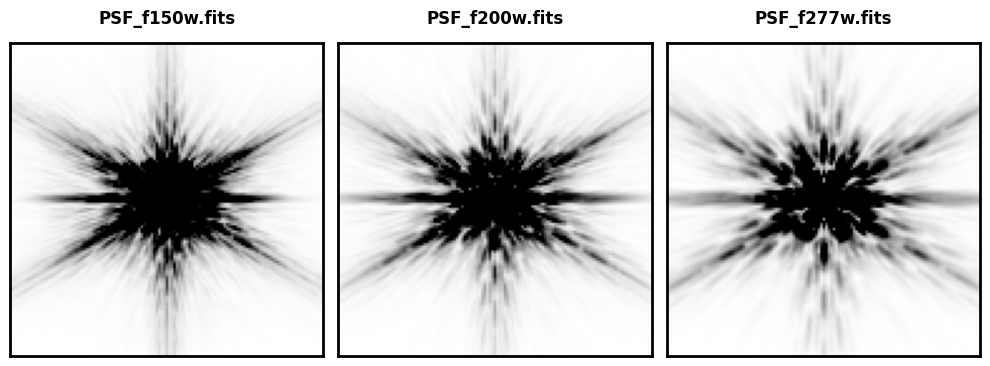

In [10]:
fig, axs = plt.subplots(1, len(psf_image_list), figsize=(10, 4))
interval = ZScaleInterval()
for i in range(len(psf_image_list)):
    psf_data = fits.getdata(psf_image_list[i])
    vmin, vmax = interval.get_limits(psf_data)
    ax = axs[i]
    ax.imshow(psf_data, cmap='gray_r', origin='lower', vmin=vmin, vmax=vmax)
    ax.tick_params(axis='both', length=0.0, labelleft=False, labelbottom=False)
    ax.text(0.50, 1.05, psf_image_list[i], fontsize=12.0, fontweight='bold',
            transform=ax.transAxes, ha='center', va='bottom')
plt.tight_layout()

In [11]:
input_psf_image_list = ["PSF_"+df['band'].values[i]+".fits" for i in range(n_galaxy)]
input_psf_image_list  # input PSF image list with an order of galaxy ID

['PSF_f150w.fits',
 'PSF_f150w.fits',
 'PSF_f150w.fits',
 'PSF_f200w.fits',
 'PSF_f277w.fits']

# 4. Running GALFIT with a single Sersic profile

### GALFIT configuration (``*.feedme``)
### For more detailed parameter configurations, please refer to [the GALFIT user manual](https://users.obs.carnegiescience.edu/peng/work/galfit/README.pdf) (from Page 31).

In [12]:
def config_galfit(galaxy_id, input_image_name, output_image_name, psf_image_name,
                  # mask_image_name=None, constraint_file=None,
                  xmin=1, xmax=250, xcenter=125,
                  ymin=1, ymax=250, ycenter=125,
                  conv_box=300,
                  mag_zero=28.9, pixel_scale=0.04,
                  mag_init=20.0, size_init=10.0, sersic_init=1.0,
                  ba_init=0.5, pa_init=45.0):
    config_file = f"{galaxy_id:05d}.feedme"
    f = open(config_file, 'w')

    # ----- Image parameters ----- #
    f.write("A) "+input_image_name+"\n")  # Input data image
    f.write("B) "+output_image_name+"\n")  # Output data image block
    f.write("C) none\n")  # Sigma image name
    f.write("D) "+psf_image_name+"\n")  # Input PSF image
    f.write("E) 1\n")  # PSF find sampling factor relative to data
    f.write("F) none\n")  # Bad pixel mask
    f.write("G) none\n")  # File with parameter constraints
    f.write(f"H) {xmin:d} {xmax:d} {ymin:d} {ymax:d}\n")  # Image region to fit
    f.write(f"I) {conv_box:d} {conv_box:d}\n")  # Size of the convolution box (x y)
    f.write(f"J) {mag_zero:.4f}\n")  # Magnitude photometric zeropoint
    f.write(f"K) {pixel_scale:.3f} {pixel_scale:.3f}\n")  # Plate scale (dx dy) [arcsec per pixel]
    f.write("O) regular\n")  # Display type (regular, curses, both)
    f.write("P) 0\n\n")  # Options (0 = normal run; 1,2 = make model/imgblock & quit)

    # ----- Sersic component ----- #
    f.write("0) sersic\n")  # Object type
    f.write(f"1) {xcenter:.2f} {ycenter:.2f} 1 1\n")  # Position (x, y)
    f.write(f"3) {mag_init:.3f} 1\n")  # Total magnitude [mag]
    f.write(f"4) {size_init:.2f} 1\n")  # R_e [pixel]
    f.write(f"5) {sersic_init:.1f} 1\n")  # Sersic exponent
    f.write(f"9) {ba_init:.3f} 1\n")  # Axis ratio (b/a)
    f.write(f"10) {pa_init:.2f} 1\n")  # Position angle (PA)
    f.write("Z) 0\n\n")  # Skip this model in output image? (yes=1, no=0)

    # ----- Sky component ----- #
    f.write("0) sky\n")
    f.write(f"1) 0.0 1\n")  # Sky background
    f.write(f"2) 0.0 1\n")  # dsky/dx
    f.write(f"3) 0.0 1\n")  # dsky/dy
    f.write("Z) 0 1\n\n")  # Skip this model in output image?
    
    f.close()

    return config_file

In [13]:
df

,ID,ra,dec,z,z_flag,logmass,f200w_mag,band
0,4912,110.79649,-73.44619,1.3739,spec,10.3248,22.651,f150w
1,5040,110.76382,-73.44747,1.9774,spec,11.4344,20.805,f150w
2,6609,110.76264,-73.45838,1.9832,spec,10.5966,22.415,f150w
3,8106,110.84655,-73.43377,2.1286,spec,9.6647,24.000,f200w
4,5486,110.76472,-73.45021,3.0994,spec,10.0511,24.049,f277w


### For an example, ID4912 galaxy

In [14]:
# config_galfit(galaxy_id, input_image_name, output_image_name, psf_image_name,
#                   xmin=1, xmax=250, xcenter=125,
#                   ymin=1, ymax=250, ycenter=125,
#                   conv_box=300,
#                   mag_zero=28.9, pixel_scale=0.04,
#                   mag_init=20.0, size_init=10.0, sersic_init=1.0,
#                   ba_init=0.5, pa_init=45.0)
idx_gal = 0
config_file = config_galfit(df['ID'].values[idx_gal],
                            clean_image_list[idx_gal],
                            f"Output_{df['ID'].values[idx_gal]:05d}.fits",
                            input_psf_image_list[idx_gal],
                            mag_init=df['f200w_mag'].values[idx_gal])
config_file

'04912.feedme'

In [15]:
subprocess.run(your_galfit_path+f"galfit "+config_file, shell=True, check=True)


GALFIT Version 3.0.5 -- Apr. 23, 2013




#  Input menu file: 04912.feedme


# IMAGE and GALFIT CONTROL PARAMETERS
A) Input2_04912_f150w.fits      # Input data image (FITS file)
B) Output_04912.fits      # Output data image block
C) none                # Sigma image name (made from data if blank or "none") 
D) PSF_f150w.fits          # Input PSF image and (optional) diffusion kernel
E) 1                   # PSF fine sampling factor relative to data 
F) none                # Bad pixel mask (FITS image or ASCII coord list)
G) none                # File with parameter constraints (ASCII file) 
H) 1    250  1    250  # Image region to fit (xmin xmax ymin ymax)
I) 300    300          # Size of the convolution box (x y)
J) 28.900              # Magnitude photometric zeropoint 
K) 0.040  0.040        # Plate scale (dx dy)   [arcsec per pixel]
O) regular             # Display type (regular, curses, both)
P) 0                   # Choose: 0=optimize, 1=model, 2=imgblock, 3=subcomps

# INITIAL F

CompletedProcess(args='/home/jhlee/Downloads/galfit 04912.feedme', returncode=0)

# 5. Evaluating the GALFIT output results

### The GALFIT output FITS files have four multiple frames (0-blank, 1-input, 2-model, 3-residual). 

In [16]:
galaxy_id = df['ID'].values[idx_gal]
print(galaxy_id)
output_image = f"Output_{galaxy_id:05d}.fits"
hdu = fits.open(output_image)
hdu.info()

4912
Filename: Output_04912.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU       8   (250, 250)   float32   
  1                1 ImageHDU        29   (250, 250)   float64   
  2                1 ImageHDU        43   (250, 250)   float32   
  3                1 ImageHDU         6   (250, 250)   float32   


### Displaying the GALFIT results

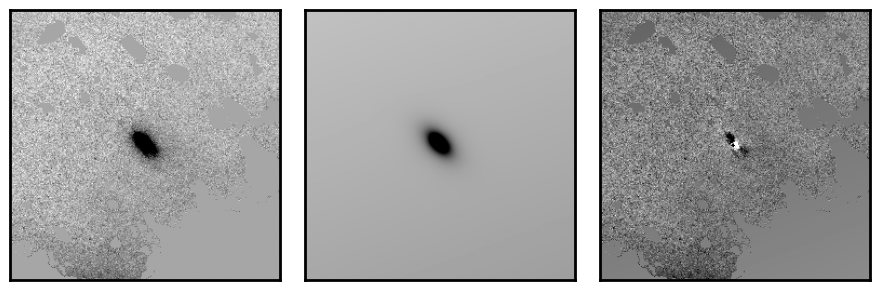

In [17]:
fig, axs = plt.subplots(1, 3, figsize=(9, 3))

# Input (cleaned) image
ax = axs[0]
ax.imshow(hdu[1].data, cmap='gray_r', origin='lower', vmin=-0.1, vmax=0.2)
ax.tick_params(axis='both', length=0.0, labelleft=False, labelbottom=False)

# GALFIT model image
ax = axs[1]
ax.imshow(hdu[2].data, cmap='gray_r', origin='lower', vmin=-0.1, vmax=0.2)
ax.tick_params(axis='both', length=0.0, labelleft=False, labelbottom=False)

# GALFIT residual (input - model) image
ax = axs[2]
vmin, vmax = interval.get_limits(hdu[3].data)
ax.imshow(hdu[3].data, cmap='gray_r', origin='lower', vmin=vmin, vmax=vmax)
ax.tick_params(axis='both', length=0.0, labelleft=False, labelbottom=False)

plt.tight_layout()

### Printing the GALFIT best-fit results

In [18]:
hdu[2].header

XTENSION= 'IMAGE   '           / IMAGE extension                                
BITPIX  =                  -32 / Bits per pixel                                 
NAXIS   =                    2 / Number of axes                                 
NAXIS1  =                  250 / Length of data axis 1                          
NAXIS2  =                  250 / Length of data axis 2                          
OBJECT  = 'model   '           / Component type                                 
COMMENT ========== GALFIT Input Parameters ==========                           
INITFILE= '04912.feedme'       / GALFIT input file                              
DATAIN  = 'Input2_04912_f150w.fits' / Input data image                          
SIGMA   = 'none    '           / Input sigma image                              
PSF     = 'PSF_f150w.fits '    / Convolution PSF and kernel                     
CONSTRNT= 'none    '           / Parameter constraint file                      
MASK    = 'none    '        

In [19]:
params = ['xcenter', 'ycenter', 'total_mag', 'Reff_pixel', 'Sersic', 'axis_ratio', 'position_angle']
hdr_kwds = ['1_XC', '1_YC', '1_MAG', '1_RE', '1_N', '1_AR', '1_PA']
best_fit_params = {}  # output results dictionary
for i in range(len(params)):
    best_fit_params[params[i]] = float(hdu[2].header[hdr_kwds[i]].split('+/-')[0])
    best_fit_params[params[i]+'_err'] = float(hdu[2].header[hdr_kwds[i]].split('+/-')[1])
best_fit_params

{'xcenter': 124.5002,
 'xcenter_err': 0.1236,
 'ycenter': 127.3487,
 'ycenter_err': 0.1297,
 'total_mag': 23.0434,
 'total_mag_err': 0.0251,
 'Reff_pixel': 10.0117,
 'Reff_pixel_err': 0.289,
 'Sersic': 1.5511,
 'Sersic_err': 0.0887,
 'axis_ratio': 0.5592,
 'axis_ratio_err': 0.0169,
 'position_angle': 43.4465,
 'position_angle_err': 1.643}